In [1]:
import pandas as pd
import numpy as np
import random
import time

<IPython.core.display.Javascript object>


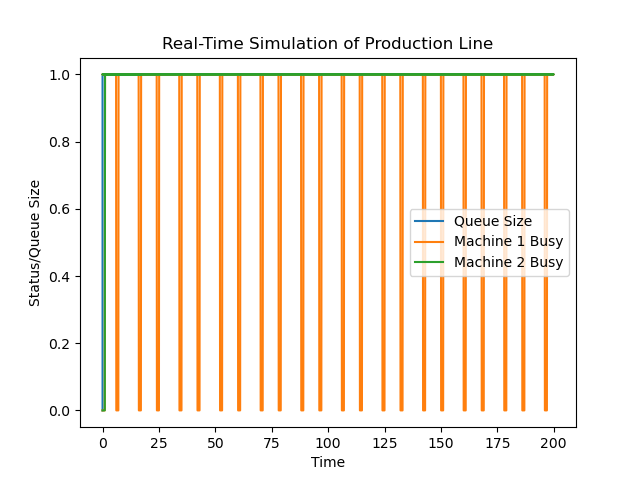

In [4]:
%matplotlib notebook
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False

    def process(self, product, current_time):
        self.busy = True
        if self.current_product != product:
            setup_time = self.setup_times[self.current_product][product] if self.current_product is not None else 0
        else:
            setup_time = 0
        
        self.current_product = product
        self.finish_time = current_time + self.processing_times[product] + setup_time
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time:
            self.busy = False

class ProductionLine:
    def __init__(self, machine1_times, machine1_setups, machine2_times, machine2_setups, arrival_rate):
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = Machine(machine2_times, machine2_setups)
        self.arrival_rate = arrival_rate
        self.queue = []
        self.next_arrival = 0
        self.finished_products = []
        self.times = []
        self.queue_sizes = []
        self.product_in_machine1 = []
        self.product_in_machine2 = []

    def add_item(self, product, current_time):
        self.queue.append((product, current_time + self.arrival_rate))

    def run_step(self, current_time):
        self.times.append(current_time)
        self.queue_sizes.append(len(self.queue))
        self.product_in_machine1.append(1 if self.machine1.busy else 0)
        self.product_in_machine2.append(1 if self.machine2.busy else 0)
        
        if self.queue and current_time >= self.queue[0][1]:
            product, arrival_time = self.queue.pop(0)
            if not self.machine1.busy:
                finish_time_machine1 = self.machine1.process(product, current_time)
                if finish_time_machine1 >= self.machine2.finish_time:
                    finish_time_machine2 = self.machine2.process(product, finish_time_machine1)
                    self.finished_products.append((product, finish_time_machine2))
        
        if current_time >= self.next_arrival:
            self.add_item(0 if len(self.finished_products) % 2 == 0 else 1, current_time)  # Alternate products
            self.next_arrival += self.arrival_rate

        self.machine1.update(current_time)
        self.machine2.update(current_time)

def animate(i, production_line):
    production_line.run_step(i)
    ax.clear()
    ax.plot(production_line.times, production_line.queue_sizes, label='Queue Size')
    ax.plot(production_line.times, production_line.product_in_machine1, label='Machine 1 Busy')
    ax.plot(production_line.times, production_line.product_in_machine2, label='Machine 2 Busy')
    ax.set_title('Real-Time Simulation of Production Line')
    ax.set_xlabel('Time')
    ax.set_ylabel('Status/Queue Size')
    ax.legend()

# Define processing and setup times
machine1_times = {0: 5, 1: 7}
machine1_setups = {None: {0: 0, 1: 0}, 0: {1: 2}, 1: {0: 2}}
machine2_times = {0: 3, 1: 4}
machine2_setups = {None: {0: 0, 1: 0}, 0: {1: 1}, 1: {0: 1}}
arrival_rate = 10  # Time between arrivals

# Create the figure for plotting
fig, ax = plt.subplots()
production_line = ProductionLine(machine1_times, machine1_setups, machine2_times, machine2_setups, 1)

# Run the animation
ani = FuncAnimation(fig, animate, frames=np.arange(0, 200, 0.1), fargs=(production_line,), interval=10)
plt.show()
